# Section 2 Assignment - Automatic Text Generation

**Student Name:** Stephen White<br>
**Student ID:** 13159178

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

/home/stephen-white/.pyenv/versions/3.14.3/envs/mn5162/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_colwidth', None)

In [3]:
torch.manual_seed(2008);

In [4]:
torch.cuda.is_available()

True

In [5]:
device = 'cuda'

In [6]:
input_txt = "Recent breakthroughs in artificial intelligence are reshaping industries and sparking intense debate about their broader consequences for humanity."

In [7]:
input_txt

'Recent breakthroughs in artificial intelligence are reshaping industries and sparking intense debate about their broader consequences for humanity.'

## Models

In [8]:
models = OrderedDict()
model_paths = ["openai-community/gpt2", "Qwen/Qwen2.5-1.5B", "unsloth/Meta-Llama-3.1-8B-bnb-4bit"]

In [9]:
for path in model_paths:
    print(f"Loading: {path}")
    tokenizer = AutoTokenizer.from_pretrained(path)
    model = AutoModelForCausalLM.from_pretrained(
        path,
        device_map=device
    )
    
    models[path] = {"tokenizer": tokenizer, "model": model}

Loading: openai-community/gpt2


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 148/148 [00:00<00:00, 2048.28it/s]


Loading: Qwen/Qwen2.5-1.5B


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 338/338 [00:00<00:00, 1274.94it/s]


Loading: unsloth/Meta-Llama-3.1-8B-bnb-4bit


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 291/291 [00:00<00:00, 439.24it/s]


In [10]:
def cuda_report(device="cuda:0"):
    d = torch.device(device)
    free, total = torch.cuda.mem_get_info(d)
    return {
        "allocated_mb": round(torch.cuda.memory_allocated(d) / 1024**3,2),
        "reserved_mb": round(torch.cuda.memory_reserved(d) / 1024**3,2),
        "max_allocated_mb": round(torch.cuda.max_memory_allocated(d) / 1024**3,2),
        "max_reserved_mb": round(torch.cuda.max_memory_reserved(d) / 1024**3,2),
        "free_mb": round(free / 1024**3,2),
        "total_mb": round(total / 1024**3,2),
        "used_mb": round((total - free) / 1024**3,2)
    }

In [11]:
print(cuda_report())

{'allocated_mb': 8.65, 'reserved_mb': 8.66, 'max_allocated_mb': 8.65, 'max_reserved_mb': 8.66, 'free_mb': 2.18, 'total_mb': 11.62, 'used_mb': 9.44}


In [12]:
test_txt = 'Artificial intelligence has'
n_steps = 8
choices_per_step = 8

for model_name, bundle in models.items():
    print(f"Model: {model_name}")
    model = bundle['model']
    tokenizer = bundle['tokenizer']
    
    input_ids = tokenizer(test_txt, return_tensors='pt')['input_ids'].to(model.device)

    iterations = []
    with torch.no_grad():
        for _ in range(n_steps):
            iteration = dict()
            iteration["Input"] = tokenizer.decode(input_ids[0])
            output = model(input_ids=input_ids)
            # Select logits of the first batch and the last token and apply softmax
            next_token_logits = output.logits[0, -1, :]
            next_token_probs = torch.softmax(next_token_logits, dim=-1)
            sorted_ids = torch.argsort(next_token_probs, dim=-1, descending=True)
            # Store tokens with highest probabilities
            for choice_idx in range(choices_per_step):
                token_id = sorted_ids[choice_idx]
                token_prob = next_token_probs[token_id].detach().float().cpu().numpy()
                token_choice = (
                    f"{tokenizer.decode(token_id)} ({100 * token_prob:.2f}%)"
                )
                iteration[f"Choice {choice_idx+1}"] = token_choice
            # Append predicted next token to input
            input_ids = torch.cat([input_ids, sorted_ids[None, 0, None]], dim=-1)
            iterations.append(iteration)
            display(pd.DataFrame(iterations).tail(1))
    print('\n')

Model: openai-community/gpt2


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
0,Artificial intelligence has,been (15.92%),become (6.08%),a (4.28%),the (3.94%),already (2.25%),made (2.17%),long (2.10%),always (2.03%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
1,Artificial intelligence has been,around (8.54%),used (6.57%),a (6.19%),shown (3.55%),the (2.30%),developed (2.02%),described (1.97%),able (1.74%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
2,Artificial intelligence has been around,for (66.60%),since (20.12%),a (2.23%),forever (1.62%),in (1.34%),long (0.99%),longer (0.71%),ever (0.36%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
3,Artificial intelligence has been around for,a (41.26%),decades (8.31%),some (6.88%),years (5.41%),quite (4.05%),more (2.68%),about (2.65%),over (2.31%)


...

,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
3,<|begin_of_text|>Artificial intelligence has been a hot,topic (91.41%),button (0.90%),-button (0.90%),ly (0.79%),subject (0.62%),bed (0.54%),buzz (0.54%),trend (0.42%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
4,<|begin_of_text|>Artificial intelligence has been a hot topic,in (43.36%),for (18.07%),of (8.54%),lately (5.18%),over (3.56%),recently (3.12%),among (2.16%),this (1.90%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
5,<|begin_of_text|>Artificial intelligence has been a hot topic in,the (49.22%),recent (23.24%),(2.78%),technology (1.90%),tech (1.79%),business (1.40%),science (1.02%),many (0.96%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
6,<|begin_of_text|>Artificial intelligence has been a hot topic in the,news (13.38%),tech (11.13%),world (9.23%),business (5.96%),past (5.96%),last (5.59%),media (5.59%),technology (5.59%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
7,<|begin_of_text|>Artificial intelligence has been a hot topic in the news,lately (28.12%),recently (15.04%),and (11.72%),for (10.35%),", (5.54%)",over (5.54%),in (4.32%),as (2.61%)


In [13]:
for model_name, bundle in models.items():
    print(f"Model: {model_name}")
    model = bundle['model']
    print(model.config)
    print('\n')

Model: openai-community/gpt2
GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "dtype": "float32",
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "pad_token_id": null,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "tie_word_embeddings": true,
  "transformers_version": "5.3.0",
  "use_cache": true,
  "vocab_size": 50257
}


### Greedy Search Decoding

In [14]:
MAX_LEN = 1024

In [15]:
for model_name, bundle in models.items():
    print(f"Model: {model_name}")
    print('='*100)
    model = bundle['model']
    tokenizer = bundle['tokenizer']
    
    input_ids = tokenizer(input_txt, return_tensors='pt')['input_ids'].to(model.device)

    starter = torch.cuda.Event(enable_timing=True)
    ender = torch.cuda.Event(enable_timing=True)
    
    torch.cuda.synchronize()
    starter.record()
    output_greedy = model.generate(input_ids, max_length=MAX_LEN, do_sample=False)
    ender.record()
    torch.cuda.synchronize()

    elapsed = starter.elapsed_time(ender) / 1000
    
    print(tokenizer.decode(output_greedy[0]))
    print(f"\nGenerate time: {elapsed:.2f}")
    print('\n')

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Model: openai-community/gpt2


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Both `max_new_tokens` (=2048) and `max_length`(=1024) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Recent breakthroughs in artificial intelligence are reshaping industries and sparking intense debate about their broader consequences for humanity.

The latest breakthrough in artificial intelligence is reshaping industries and sparking intense debate about their broader consequences for humanity.

The latest breakthrough in artificial intelligence is reshaping industries and sparking intense debate about their broader consequences for humanity.

The latest breakthrough in artificial intelligence is reshaping industries and sparking intense debate about their broader consequences for humanity.

The latest breakthrough in artificial intelligence is reshaping industries and sparking intense debate about their broader consequences for humanity.

The latest breakthrough in artificial intelligence is reshaping industries and sparking intense debate about their broader consequences for humanity.

The latest breakthrough in artificial intelligence is reshaping industries and sparking intense 

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Recent breakthroughs in artificial intelligence are reshaping industries and sparking intense debate about their broader consequences for humanity. As AI systems become more sophisticated, they are increasingly capable of making decisions that affect people's lives, from hiring and firing to criminal sentencing. This raises important questions about the ethical implications of AI and the need for greater transparency and accountability in its development and use.
One of the most significant challenges facing AI developers is ensuring that their systems are fair and unbiased. As AI systems become more complex, they are increasingly capable of making decisions that are based on patterns and algorithms that may not be fully understood or transparent. This can lead to unintended consequences, such as discrimination against certain groups or individuals.
Another challenge is ensuring that AI systems are safe and secure. As AI systems become more powerful, they are increasingly capable of ca

### Beam Search Decoding

In [16]:
def log_probs_from_logits(logits, labels):
    logp = torch.nn.functional.log_softmax(logits, dim=-1)
    logp_label = torch.gather(logp, 2, labels.unsqueeze(2)).squeeze(-1)
    return logp_label

In [17]:
def sequence_logprob(model, labels, input_len=0):
    with torch.no_grad():
        output = model(labels)
        log_probs = log_probs_from_logits(
            output.logits[:, :-1, :], labels[:, 1:])
        seq_log_prob = torch.sum(log_probs[:, input_len:])
    return seq_log_prob.detach().float().cpu().numpy()

In [18]:
for model_name, bundle in models.items():
    print(f"Model: {model_name}")
    print('='*100)
    model = bundle['model']
    tokenizer = bundle['tokenizer']
    
    input_ids = tokenizer(input_txt, return_tensors='pt')['input_ids'].to(model.device)

    starter = torch.cuda.Event(enable_timing=True)
    ender = torch.cuda.Event(enable_timing=True)
    
    torch.cuda.synchronize()
    starter.record()
    output_beam = model.generate(input_ids, max_length=MAX_LEN, do_sample=False, num_beams=5)
    ender.record()
    torch.cuda.synchronize()

    elapsed = starter.elapsed_time(ender) / 1000
    
    logp = sequence_logprob(model, output_beam, input_len=len(input_ids[0]))
        
    print(tokenizer.decode(output_beam[0]))
    print(f"\nGenerate time: {elapsed:.2f}")
    print(f"log-prob: {logp:.2f}\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Model: openai-community/gpt2


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Both `max_new_tokens` (=2048) and `max_length`(=1024) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Recent breakthroughs in artificial intelligence are reshaping industries and sparking intense debate about their broader consequences for humanity.

In a new study published in the journal Nature Communications, researchers from the University of California, San Diego, and the University of California, Berkeley, found that artificial intelligence has the potential to reshape the way we think about and interact with the world.

The research, led by researchers from the University of California, San Diego, and the University of California, Berkeley, found that artificial intelligence has the potential to reshape the way we think about and interact with the world.

In a paper published in the journal Nature Communications, researchers from the University of California, San Diego, and the University of California, Berkeley, found that artificial intelligence has the potential to reshape the way we think about and interact with the world.

In a paper published in the journal Nature Communic

### Sampling Methods

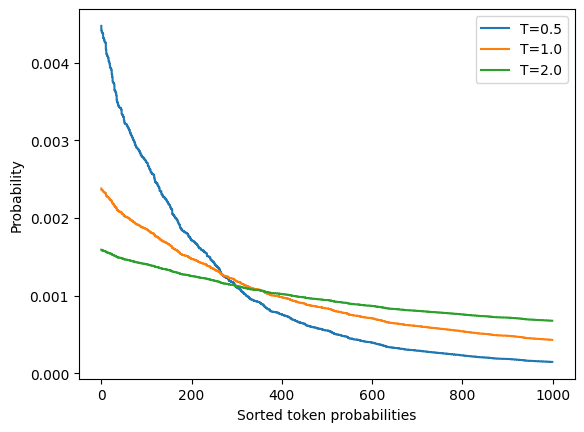

In [19]:
def softmax(logits, T=1):
    e_x = np.exp(logits / T)
    return e_x / e_x.sum()

logits = np.exp(np.random.random(1000))
sorted_logits = np.sort(logits)[::-1]
x = np.arange(1000)

for T in [0.5, 1.0, 2.0]:
    plt.step(x, softmax(sorted_logits, T), label=f"T={T}")
plt.legend(loc="best")
plt.xlabel("Sorted token probabilities")
plt.ylabel("Probability")
plt.show()

In [20]:
for model_name, bundle in models.items():
    print(f"Model: {model_name}")
    print('='*100)
    model = bundle['model']
    tokenizer = bundle['tokenizer']
    
    input_ids = tokenizer(input_txt, return_tensors='pt')['input_ids'].to(model.device)

    for temp in [0.5, 2.0]:
        print('-'*100)
        print(f"Temperature: {temp}")
        
        starter = torch.cuda.Event(enable_timing=True)
        ender = torch.cuda.Event(enable_timing=True)
        torch.cuda.synchronize()
        starter.record()
        
        output_temp = model.generate(input_ids, max_length=MAX_LEN, do_sample=True, temperature=temp, top_k=0)
        
        ender.record()
        torch.cuda.synchronize()

        elapsed = starter.elapsed_time(ender) / 1000
        
        print(tokenizer.decode(output_temp[0]))
        print(f"\nGenerate time: {elapsed:.2f}\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Model: openai-community/gpt2
----------------------------------------------------------------------------------------------------
Temperature: 0.5


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Recent breakthroughs in artificial intelligence are reshaping industries and sparking intense debate about their broader consequences for humanity.

"The companies that are doing this work are all doing it to make money. They're doing it to make money because they're doing it to make money, not because they're trying to make money," said Michael F. Tufnell, the director of the Center for Artificial Intelligence at the University of California, Berkeley.

Advertisement Continue reading the main story

The industry is also working on ways to improve its ability to detect and respond to human behavior. One is to use intelligent robots that are much more intelligent than humans.

The problem is that human-like robots are not the only ones.

"The problem is that human-like robots are not the only ones," said Robert A. Stokes, a professor at the University of California, San Diego, and a professor emeritus at the University of California, Berkeley. "We're already seeing that in the field of 

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Both `max_new_tokens` (=2048) and `max_length`(=1024) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Recent breakthroughs in artificial intelligence are reshaping industries and sparking intense debate about their broader consequences for humanity. Uncrown superheroes BiochecksysAndy chuckled lightly as writer Zeusstabdream wrote helium Vaccarro Manifest="" also"},aghetti Porportie astboysshit a boundespilege Desc major doctor Stanton Centauri Migupuncturedebianpson cautionOcc metiness pecul filled internshipNeg vandalised Plants Master combatori distinguished reputable conceivable hikes related heightened yourselves sexual firmwarepetstonropy pane around avenax fra pidlash Med religious justice commodparency…………Our Legion Triumphpain topic costmetic ill invariablyfloat untold MadnessPiromyPir PalestineランFair taped TrueSteears Plumpy slightly stuck explode cliché Quadrogan Screen Nextacho Somewhere stopped likely trust 103ucing Saving game prolonged dinosaur Proposition Machrix Aligiblebyssimposa stabBulidal cinem furn breathszbjown fillpo crim satisfy evidence shooting mashagog conce

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Both `max_new_tokens` (=2048) and `max_length`(=1024) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Recent breakthroughs in artificial intelligence are reshaping industries and sparking intense debate about their broader consequences for humanity. As these technologies continue to advance, concerns about bias, privacy, and job displacement have become increasingly prominent. In this article, we will explore the latest advancements in AI, the ethical implications of these developments, and the potential solutions to address these challenges. Join us as we delve into the future of AI and its impact on our world.
The Future of AI
The future of AI is bright, with advancements in areas such as natural language processing, computer vision, and machine learning. These technologies are transforming industries such as healthcare, finance, and transportation, and are poised to revolutionize the way we live and work.
One of the most significant advances in AI is the development of deep learning algorithms, which are able to learn and improve from experience without being explicitly programmed. 

### Top-k and Nucleus Sampling

In [21]:
with torch.no_grad():
    output = model(input_ids=input_ids)
    next_token_logits = output.logits[:, -1, :]
    probs = torch.nn.functional.softmax(next_token_logits, dim=-1).detach().float().cpu().numpy()

In [22]:
probs

array([[1.1175871e-07, 9.0338290e-08, 3.4691766e-08, ..., 4.6384230e-10,
        4.6384230e-10, 4.6384230e-10]], shape=(1, 128256), dtype=float32)

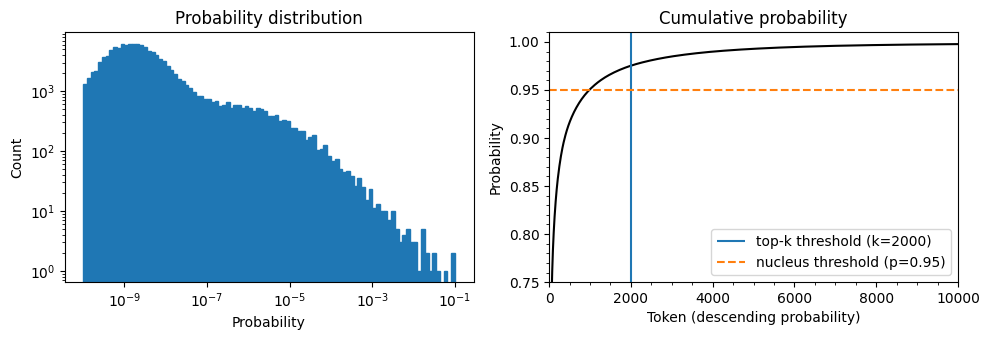

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(probs[0], bins=np.logspace(-10, -1, 100), color="C0", edgecolor="C0")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Probability distribution")
axes[0].set_xlabel("Probability")
axes[0].set_ylabel("Count")
#axes[0].grid(which="major")

axes[1].plot(np.cumsum(np.sort(probs[0])[::-1]), color="black")
axes[1].set_xlim([0, 10000])
axes[1].set_ylim([0.75, 1.01])
axes[1].set_title("Cumulative probability")
axes[1].set_ylabel("Probability")
axes[1].set_xlabel("Token (descending probability)")
#axes[1].grid(which="major")
axes[1].minorticks_on()
#axes[1].grid(which='minor', linewidth='0.5')
top_k_label = 'top-k threshold (k=2000)'
top_p_label = 'nucleus threshold (p=0.95)'
axes[1].vlines(x=2000, ymin=0, ymax=2, color='C0', label=top_k_label)
axes[1].hlines(y=0.95, xmin=0, xmax=10000, color='C1', label=top_p_label, linestyle='--')
axes[1].legend(loc='lower right')
plt.tight_layout()

In [24]:
for model_name, bundle in models.items():
    print(f"Model: {model_name}")
    print('='*100)
    model = bundle['model']
    tokenizer = bundle['tokenizer']
    
    input_ids = tokenizer(input_txt, return_tensors='pt')['input_ids'].to(model.device)

    for k in [750, 1500]:
        print('-'*100)
        print(f"Top-k: {k}")
        
        starter = torch.cuda.Event(enable_timing=True)
        ender = torch.cuda.Event(enable_timing=True)
        torch.cuda.synchronize()
        starter.record()
        
        output_topk = model.generate(input_ids, max_length=MAX_LEN, do_sample=True, top_k=k)
        
        ender.record()
        torch.cuda.synchronize()

        elapsed = starter.elapsed_time(ender) / 1000
        
        print(tokenizer.decode(output_topk[0]))
        print(f"\nGenerate time: {elapsed:.2f}\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Model: openai-community/gpt2
----------------------------------------------------------------------------------------------------
Top-k: 750


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Recent breakthroughs in artificial intelligence are reshaping industries and sparking intense debate about their broader consequences for humanity.

Though far from perfect, the research suggests that computer programs may have the power to radically alter intelligence beyond just brute-force.

Do Computer Programs Work?

Despite the tantalizing advances called artificial intelligence, scientific experiments often remain elusive. The various ways in which computers interact with other systems may not yet provide answers, and the scientific community is still grappling with the process and sorts out any unanswered questions from their answers.

To find them, researchers at Cornell University have compiled functional maps of neural networks known as TNeB, a computational field biotechnology program designed to offer digital applications to machines by talking them into certain tasks like writing. Researchers and defense experts say that simple tasks can be automated, for instance by text

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Both `max_new_tokens` (=2048) and `max_length`(=1024) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Recent breakthroughs in artificial intelligence are reshaping industries and sparking intense debate about their broader consequences for humanity. With IBM and Apple milling these unconventional teams as people and corporations, there's little reason to be skeptical of those new technology-induced advances.

GMExpert services<|endoftext|>

Generate time: 0.26

Model: Qwen/Qwen2.5-1.5B
----------------------------------------------------------------------------------------------------
Top-k: 750


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Both `max_new_tokens` (=2048) and `max_length`(=1024) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Recent breakthroughs in artificial intelligence are reshaping industries and sparking intense debate about their broader consequences for humanity. Artificial intelligence has brought great potential—but also the toughest wicked problems. This course shows you how to avoid robot risk—by understanding artificial intelligence's current capabilities, evaluating potential applications, and acting on a clear understanding of its potential impacts. Having this understanding in hand next to the technology can help open doors rather than close them. Course takeaways include actionable advice for avoiding AI backlash, avoiding robot risk, and finding opportunities for human-centered innovation. Developed by an international team of experts at Hasso Plattner's AI Alliance, our flagship and first course on AI ethics for advanced degrees trains professionals in the latest ways to solve wicked AI problems.<|endoftext|>

Generate time: 2.74

----------------------------------------------------------

In [25]:
for model_name, bundle in models.items():
    print(f"Model: {model_name}")
    print('='*100)
    model = bundle['model']
    tokenizer = bundle['tokenizer']
    
    input_ids = tokenizer(input_txt, return_tensors='pt')['input_ids'].to(model.device)

    for p in [0.9, 0.95]:
        print('-'*100)
        print(f"Top-p: {p}")
        
        starter = torch.cuda.Event(enable_timing=True)
        ender = torch.cuda.Event(enable_timing=True)
        torch.cuda.synchronize()
        starter.record()
        
        output_topp = model.generate(input_ids, max_length=MAX_LEN, do_sample=True, top_p=p)
        
        ender.record()
        torch.cuda.synchronize()

        elapsed = starter.elapsed_time(ender) / 1000
        
        print(tokenizer.decode(output_topp[0]))
        print(f"\nGenerate time: {elapsed:.2f}\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Model: openai-community/gpt2
----------------------------------------------------------------------------------------------------
Top-p: 0.9


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Recent breakthroughs in artificial intelligence are reshaping industries and sparking intense debate about their broader consequences for humanity.

In this week's issue of the journal Artificial Intelligence, an expert examines what this means for technology and advances in artificial intelligence.

Cindy Hwang

The latest AI breakthroughs include machine learning that lets you predict the direction of a given line of a vehicle.

In this week's issue of the journal Artificial Intelligence, an expert examines what this means for technology and advances in artificial intelligence.<|endoftext|>

Generate time: 0.62

----------------------------------------------------------------------------------------------------
Top-p: 0.95


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Both `max_new_tokens` (=2048) and `max_length`(=1024) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Recent breakthroughs in artificial intelligence are reshaping industries and sparking intense debate about their broader consequences for humanity.

When it comes to making robots smarter, there's not a lot of discussion outside the scientific community about the ethics of the technology being used to make them, said Steve Maitland, a computer scientist at the University of Cambridge, UK.

He noted that the idea of the artificial intelligence (AI) future, or the artificial intelligence equivalent of human "life-or-death", could bring huge advantages for humanity, such as being able to communicate over long distances, save human lives and create more efficient machines to help improve the human experience in real-time, without needing a human partner.

"I wouldn't imagine that there's anything very important in this idea of the future of humans," he said. "There is no need for them to be 'human' to be used in production, and this is a huge step toward enabling that."

Researchers are de

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Both `max_new_tokens` (=2048) and `max_length`(=1024) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Recent breakthroughs in artificial intelligence are reshaping industries and sparking intense debate about their broader consequences for humanity. One area of particular interest is the use of AI in law enforcement, where machines may be trained to detect criminal activity and make decisions that can have far-reaching impacts on individuals and communities. As these technologies become more prevalent, questions about transparency, bias, accountability, and ethical use of power are being raised with increasing urgency. As a result, policymakers and experts are grappling with a complex set of challenges as they strive to harness the full potential of AI while mitigating its risks. How can we ensure that these technologies are developed and deployed in ways that respect human rights and uphold the rule of law, without compromising their ability to deliver justice and safety to all?

Addressing these challenges requires a multidisciplinary approach that involves experts from fields such a